In [1]:
import Modules.constants_external as constants 
import Modules.ds_loader as ds_loader
from tensorflow import keras
import numpy as np
import os
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from signal_grad_cam import TfCamBuilder

In [2]:
print(constants.FINAL_SIZE)

500


In [3]:
X_test, y_test = ds_loader.load_data(constants.DATASET)
print(X_test.shape)
print(y_test.shape)

[ OK ] Loaded 10834 samples with shape (500, 12)
(10834, 500, 12)
(10834,)


In [4]:
norm_X = []
for x in X_test:
    norm_x = (x - np.min(x)) / (np.max(x) - np.min(x))
    norm_X.append(norm_x)

norm_X = np.stack(norm_X, axis=0, dtype=np.float32)
print(norm_X.shape)

(10834, 500, 12)


In [5]:
# src\Models\RES_W500_T04.h5
model = keras.models.load_model("src\Models\RES_W500_T04.h5")
print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 500, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 500, 128)  │      4,736 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 500, 128)  │          0 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 500, 128)  │        512 │ re_lu[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 500, 8)    │      3,080 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 500, 8)    │          0 │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 8)    │         32 │ re_lu_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 500, 8)    │        104 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 500, 8)    │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 500, 8)    │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 8)    │         32 │ re_lu_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 248, 8)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 248, 128)  │      3,200 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 248, 128)  │          0 │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 248, 128)  │        512 │ re_lu_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 248, 8)    │      3,080 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 248, 8)    │          0 │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 248, 8)    │         32 │ re_lu_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 248, 8)    │         72 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 248, 8)    │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 38,654 (151.00 KB)

 Trainable params: 37,212 (145.36 KB)

 Non-trainable params: 1,440 (5.62 KB)

 Optimizer params: 2 (12.00 B)

None


339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.66      0.82      0.73      1008
           1       0.28      0.97      0.44       229
           2       0.26      0.95      0.40       456
           3       1.00      0.77      0.87      9141

    accuracy                           0.79     10834
   macro avg       0.55      0.88      0.61     10834
weighted avg       0.92      0.79      0.83     10834

AUC: 0.9662301271787019


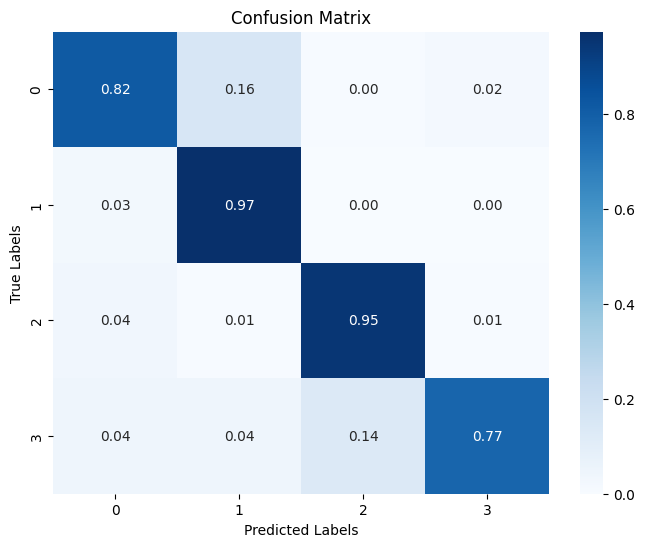

In [12]:
# Get model predictions (probabilities)
y_pred = model.predict(norm_X)

# Convert to class predictions using argmax since this is multi-class with 4 outputs
y_pred_class = np.argmax(y_pred, axis=1)

# Calculate metrics
print("Classification Report (Test Data):")
print(sklearn.metrics.classification_report(y_test, y_pred_class))

# For multi-class ROC AUC score, use OVR (One-vs-Rest) approach
auc = sklearn.metrics.roc_auc_score(y_test, y_pred, multi_class='ovr')
print(f"AUC: {auc}")

# Generate normalized confusion matrix
cm = sklearn.metrics.confusion_matrix(y_test, y_pred_class, normalize='true')

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=[0, 1, 2, 3], yticklabels=[0, 1, 2, 3])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [12]:
data_labels_0 = [y for y in y_test[:10]]
data_labels_1 = [y for y in y_test[1008:1018]]
data_labels_2 = [y for y in y_test[1237:1247]]
data_labels_3 = [y for y in y_test[1693:1703]]
data_labels_list = data_labels_0 + data_labels_1 + data_labels_2 + data_labels_3
print(len(data_labels_list))

data_list_0 = [x for x in norm_X[:10]]
data_list_1 = [x for x in norm_X[1008:1018]]
data_list_2 = [x for x in norm_X[1237:1247]]
data_list_3 = [x for x in norm_X[1693:1703]]
data_list = data_list_0 + data_list_1 + data_list_2 + data_list_3
print(len(data_list))
print(data_list[0].shape)

40
40
(500, 12)


In [14]:
ls0 = [str(i) for i in range(10)]
ls1 = [str(i) for i in range(1008,1018)]
ls2 = [str(i) for i in range(1237,1247)]
ls3 = [str(i) for i in range(1693,1703)]
item_names = ls0 + ls1 + ls2 + ls3
print(item_names)

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '1008', '1009', '1010', '1011', '1012', '1013', '1014', '1015', '1016', '1017', '1237', '1238', '1239', '1240', '1241', '1242', '1243', '1244', '1245', '1246', '1693', '1694', '1695', '1696', '1697', '1698', '1699', '1700', '1701', '1702']


In [ ]:
target_classes = [0, 1, 2, 3]
class_labels = ["Atrial Fibrillation", "Supraventricular Tachycardia", "Sinus Bradycardia", "Sinus Rhythm"]
# Draw CAMs
cam_builder = TfCamBuilder(model, class_names=class_labels, time_axs=0)
target_layers_names = ["conv1d_12"]
cams, predicted_probs_dict, bar_ranges = cam_builder.get_cam(data_list, data_labels=data_labels_list,
                                                        target_classes=target_classes,
                                                        explainer_types="Grad-CAM",
                                                        target_layers=target_layers_names, softmax_final=False,
                                                        data_names=item_names, data_sampling_freq=50, dt=1, results_dir_path="./output_cams")

# Explain different input channels
comparison_algorithm = "Grad-CAM"
for i in range(12):
    selected_channels_indices = [i]
    cam_builder.single_channel_output_display(data_list=data_list, data_labels=data_labels_list,
                                                predicted_probs_dict=predicted_probs_dict, cams_dict=cams,
                                                explainer_types=comparison_algorithm, target_classes=target_classes,
                                                target_layers=target_layers_names, desired_channels=selected_channels_indices,
                                                data_names=item_names, fig_size=(20, 10), grid_instructions=(1, len(selected_channels_indices)),
                                                bar_ranges_dict=bar_ranges,
                                                results_dir_path=f"./output_cams/channel_{i}", data_sampling_freq=50, dt=1,
                                                line_width=0.5, marker_width=30,
                                                axes_names=(None, None))

In [ ]:
# --- Config ---
excel_path = "./Data/Label_Map.xlsx"           # path to your Excel file
ecg_dir = "./Data/ECGDataDenoised/"              # directory with ECG .csv files
samples_per_class = 15
expected_leads = 12
expected_length = 500                # adjust if your ECGs are a different length

# Optional: seed for reproducibility
np.random.seed(42)

# --- Load labels ---
df = pd.read_excel(excel_path)
print(df.shape)
assert 'FileName' in df.columns and 'Rhythm' in df.columns

# --- Stratified sample ---
sampled_df = df.groupby('Rhythm', group_keys=False).apply(lambda x: x.sample(n=samples_per_class, random_state=42))
print(sampled_df.shape)

# --- Load ECGs ---
background_data = []

for _, row in sampled_df.iterrows():
    name = str(row['FileName']) + '.csv'
    filepath = os.path.join(ecg_dir, name)
    
    if not os.path.exists(filepath):
        print(f"Skipping missing file: {filepath}")
        continue
    
    ecg = pd.read_csv(filepath, header=None).values
    
    # Transpose if necessary
    if ecg.shape[0] == expected_length and ecg.shape[1] == expected_leads:
        background_data.append(ecg)

# --- Stack into array ---
background_array = np.stack(background_data)

In [ ]:
from Modules.windowshap import SlidingWindowSHAP
test_data = norm_X[:1]
print(test_data.shape)
gtw = SlidingWindowSHAP(model, stride=25, window_len=50, B_ts=background_array, test_ts=test_data, model_type='lstm')
maps = gtw.shap_values(num_output=4)

In [ ]:
from Modules.windowshap import DynamicWindowSHAP
test_data = norm_X[:1]
print(test_data.shape)
delta = 0.3
n_w = 8
btw = DynamicWindowSHAP(model, delta, n_w, background_array, test_data, model_type='lstm')
maps_dyn = gtw.shap_values(num_output=4)

In [ ]:
def heat_map(start, stop, x, shap_values, var_name='Feature 1', plot_type='bar', title=None):
    """
    A function that generates a heatmap with the temporal sequence alongside its Shapley values

    Parameters
    ----------
    start (int): the starting point of the temporal sequence
    stop (int): the ending point of the temporal sequence
    x (np.ndarray): the sequence data
    shap_values (np.ndarray): the Shapley values corresponding to the sequence data
    var_name (str): the name of the variable being plotted (default: 'Feature 1')
    plot_type (str): the type of plot to generate ('bar' or 'heat' or 'heat_abs', default: 'bar')
    title (str): the title for the plot (default: None)
    """
    import matplotlib.pyplot as plt
    from matplotlib.colors import LinearSegmentedColormap
    from matplotlib.colors import BoundaryNorm
    from textwrap import wrap
    import numpy as np; np.random.seed(1)
    
    ## ColorMap-------------------------
    # define the colormap
    cmap = plt.get_cmap('PuOr_r')

    # extract all colors from the .jet map
    cmaplist = [cmap(i) for i in range(cmap.N)]
    # create the new map
    cmap = cmap.from_list('Custom cmap', cmaplist, cmap.N)

    # define the bins and normalize and forcing 0 to be part of the colorbar!
    bounds = np.arange(np.min(shap_values),np.max(shap_values),.005)
    idx=np.searchsorted(bounds,0)
    bounds=np.insert(bounds,idx,0)
    norm = BoundaryNorm(bounds, cmap.N)
    ##------------------------------------
    
    if title is None: title = '\n'.join(wrap('{} values and contribution scores'.format(var_name), width=40))
    
    if plot_type=='heat' or plot_type=='heat_abs':
        plt.rcParams["figure.figsize"] = 9,3
        if plot_type=='heat_abs':
            shap_values = np.absolute(shap_values)
            cmap = 'Reds'
        fig, ax1 = plt.subplots(sharex=True)
        extent = [start, stop, -2, 2]
        im1 = ax1.imshow(shap_values[np.newaxis, :], cmap=cmap, norm=norm, aspect="auto", extent=extent)
        ax1.set_yticks([])
        ax1.set_xlim(extent[0], extent[1])
        ax1.title.set_text(title)
        fig.colorbar(im1, ax=ax1, pad=0.1)
        ax2 = ax1.twinx()
        ax2.plot(np.arange(start, stop), x, color='black')
    elif plot_type=='bar':
        plt.rcParams["figure.figsize"] = 8.5,2.5
        fig, ax1 = plt.subplots(sharex=True)
        mask1 = shap_values < 0
        mask2 = shap_values >= 0
        ax1.bar(np.arange(start, stop)[mask1], shap_values[mask1], color='blue', label='Negative Shapley values')
        ax1.bar(np.arange(start, stop)[mask2], shap_values[mask2], color='red', label='Positive Shapley values')
        ax1.set_title(title)
        ax2 = ax1.twinx()
        ax2.plot(np.arange(start, stop), x, 'k-', label='Observed data')
        # legends
        lines, labels = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        # ax2.legend(lines + lines2, labels + labels2, loc=0)
    
    ax1.set_xlabel('Time steps')
    if plot_type=='bar': ax1.set_ylabel('Shapley values')
    ax2.set_ylabel(var_name + ' data values')
    plt.tight_layout()
    plt.show()

In [ ]:
var = 0
heat_map(start=0, stop=500, x=norm_X[0, :, var],
         shap_values=maps[0, :, var], var_name='Variable', plot_type='bar')

In [ ]:
heat_map(start=0, stop=500, x=norm_X[0, :, var],
         shap_values=maps_dyn[0, :, var], var_name='Variable', plot_type='bar')

In [11]:
def load_and_evaluate_models(directory_path, X_test, y_test):
    directory = Path(directory_path)
    model_files = list(directory.glob("*.keras")) + list(directory.glob("*.h5"))
    
    print(f"🔍 Found {len(model_files)} model(s) in {directory_path}\n")

    for file_path in model_files:
        try:
            print(f"📦 Loading model: {file_path.name}")
            model = keras.models.load_model(file_path)
            
            y_pred = model.predict(X_test)
            y_pred_class = np.argmax(y_pred, axis=1)

            print(f"Classification Report {file_path.name}:")
            print(sklearn.metrics.classification_report(y_test, y_pred_class))

            auc = sklearn.metrics.roc_auc_score(y_test, y_pred, multi_class='ovr')
            print(f"AUC ({file_path.name}): {auc}")
            
            print(f"✅ Evaluation for {file_path.name} completed.")

        except Exception as e:
            print(f"❌ Error loading/evaluating {file_path.name}: {e}")

In [12]:
load_and_evaluate_models('src\Models', X_test=norm_X, y_test=y_test)

🔍 Found 15 model(s) in src\Models

📦 Loading model: C_RES_500_3.keras
339/339 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step
Classification Report C_RES_500_3.keras:
              precision    recall  f1-score   support

           0       0.02      0.00      0.01      1008
           1       0.02      1.00      0.04       229
           2       0.29      0.16      0.21       456
           3       1.00      0.00      0.00      9141

    accuracy                           0.03     10834
   macro avg       0.33      0.29      0.07     10834
weighted avg       0.86      0.03      0.01     10834

AUC (C_RES_500_3.keras): 0.6407203220196309
✅ Evaluation for C_RES_500_3.keras completed.
📦 Loading model: RES_500_3.keras


c:\Users\faola\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 166 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


339/339 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step
Classification Report RES_500_3.keras:
              precision    recall  f1-score   support

           0       0.12      0.27      0.17      1008
           1       0.02      0.70      0.04       229
           2       0.00      0.00      0.00       456
           3       0.00      0.00      0.00      9141

    accuracy                           0.04     10834
   macro avg       0.04      0.24      0.05     10834
weighted avg       0.01      0.04      0.02     10834

AUC (RES_500_3.keras): 0.5395912383926311
✅ Evaluation for RES_500_3.keras completed.
📦 Loading model: RES_W500_L3.keras


c:\Users\faola\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\faola\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\faola\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

339/339 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
Classification Report RES_W500_L3.keras:
              precision    recall  f1-score   support

           0       0.22      0.77      0.34      1008
           1       0.16      0.68      0.26       229
           2       0.24      0.85      0.37       456
           3       1.00      0.50      0.67      9141

    accuracy                           0.54     10834
   macro avg       0.40      0.70      0.41     10834
weighted avg       0.87      0.54      0.61     10834

AUC (RES_W500_L3.keras): 0.8512434237223953
✅ Evaluation for RES_W500_L3.keras completed.
📦 Loading model: RES_W500_L3_9662ACC.keras
339/339 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step
Classification Report RES_W500_L3_9662ACC.keras:
              precision    recall  f1-score   support

           0       0.39      0.75      0.51      1008
           1       0.30      0.85      0.45       229
           2       0.24      0.93      0.38       456
           3       0.99      0.70      0.

...

339/339 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step
Classification Report RES_W500_L4_97ACC.h5:
              precision    recall  f1-score   support

           0       0.35      0.67      0.46      1008
           1       0.22      0.97      0.36       229
           2       0.28      0.93      0.43       456
           3       0.99      0.69      0.82      9141

    accuracy                           0.71     10834
   macro avg       0.46      0.81      0.52     10834
weighted avg       0.89      0.71      0.76     10834

AUC (RES_W500_L4_97ACC.h5): 0.9103779956312803
✅ Evaluation for RES_W500_L4_97ACC.h5 completed.
📦 Loading model: RES_W500_T00.h5


339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Classification Report RES_W500_T00.h5:
              precision    recall  f1-score   support

           0       0.33      0.65      0.44      1008
           1       0.34      0.87      0.49       229
           2       0.18      0.97      0.30       456
           3       0.97      0.61      0.75      9141

    accuracy                           0.63     10834
   macro avg       0.45      0.78      0.49     10834
weighted avg       0.86      0.63      0.70     10834

AUC (RES_W500_T00.h5): 0.9078218703925129
✅ Evaluation for RES_W500_T00.h5 completed.
📦 Loading model: RES_W500_T01.h5


339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
Classification Report RES_W500_T01.h5:
              precision    recall  f1-score   support

           0       0.33      0.65      0.44      1008
           1       0.34      0.87      0.49       229
           2       0.18      0.97      0.30       456
           3       0.97      0.61      0.75      9141

    accuracy                           0.63     10834
   macro avg       0.45      0.78      0.49     10834
weighted avg       0.86      0.63      0.70     10834

AUC (RES_W500_T01.h5): 0.9078218703925129
✅ Evaluation for RES_W500_T01.h5 completed.
📦 Loading model: RES_W500_T02.h5


339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Classification Report RES_W500_T02.h5:
              precision    recall  f1-score   support

           0       0.33      0.65      0.44      1008
           1       0.34      0.87      0.49       229
           2       0.18      0.97      0.30       456
           3       0.97      0.61      0.75      9141

    accuracy                           0.63     10834
   macro avg       0.45      0.78      0.49     10834
weighted avg       0.86      0.63      0.70     10834

AUC (RES_W500_T02.h5): 0.9078218703925129
✅ Evaluation for RES_W500_T02.h5 completed.
📦 Loading model: RES_W500_T04.h5


339/339 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
Classification Report RES_W500_T04.h5:
              precision    recall  f1-score   support

           0       0.66      0.82      0.73      1008
           1       0.28      0.97      0.44       229
           2       0.26      0.95      0.40       456
           3       1.00      0.77      0.87      9141

    accuracy                           0.79     10834
   macro avg       0.55      0.88      0.61     10834
weighted avg       0.92      0.79      0.83     10834

AUC (RES_W500_T04.h5): 0.9662301271787019
✅ Evaluation for RES_W500_T04.h5 completed.
